# Import

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm

import seaborn as sns

from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Task 1 — Persiapan Data dan EDA Singkat



In [2]:
df = pd.read_csv('cc_general.csv')
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
df.drop('CUST_ID', axis= 1, inplace=True)

In [4]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [6]:
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

In [ ]:
scaler = StandardScaler()
scaled = scaler.fit_transform(df)

<Axes: >

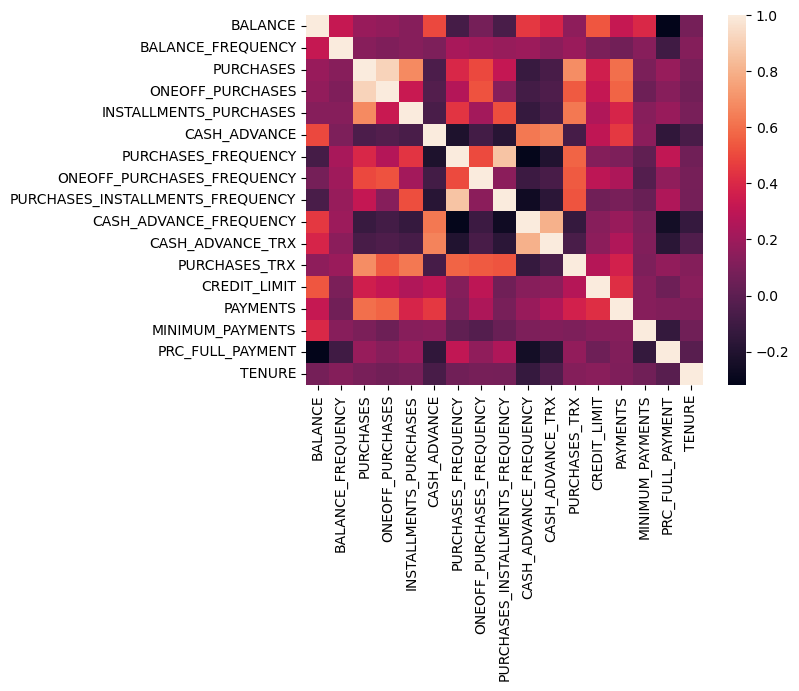

In [13]:
sns.heatmap(pd.DataFrame(scaled, columns=df.columns).corr())

# Task 2 — PCA dan Explained Variance

In [15]:
pca = PCA()
pca.fit(scaled)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


Jumlah komponen untuk minimal 80% variance: 7
Cumulative variance pada komponen ke-7: 80.75%


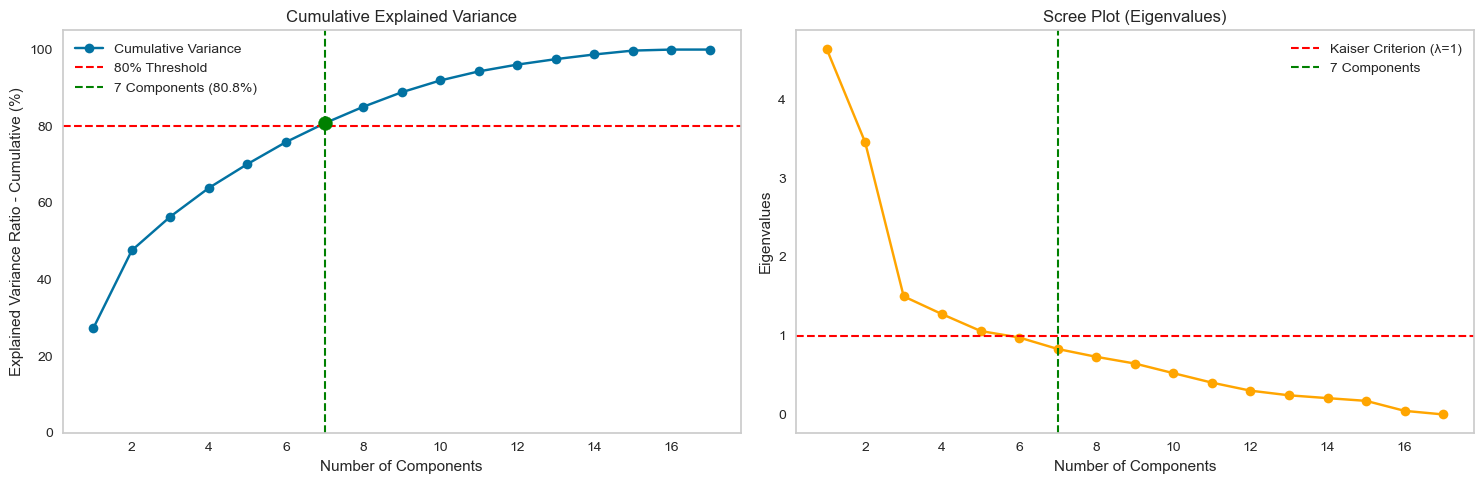

In [22]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_ * 100)

# Tentukan jumlah komponen yang menjelaskan minimal 80% variance
n_components_80 = np.argmax(cumulative_variance >= 80) + 1
print(f"Jumlah komponen untuk minimal 80% variance: {n_components_80}")
print(f"Cumulative variance pada komponen ke-{n_components_80}: {cumulative_variance[n_components_80 - 1]:.2f}%")

plt.figure(figsize=(15, 5))

# Plot Cumulative Explained Variance
plt.subplot(1, 2, 1)
plt.grid()
plt.plot(range(1, 18), cumulative_variance, marker='o', label='Cumulative Variance')

# Garis threshold 80%
plt.axhline(y=80, color='red', linestyle='--', linewidth=1.5, label='80% Threshold')

# Garis vertikal di komponen optimal
plt.axvline(x=n_components_80, color='green', linestyle='--', linewidth=1.5,
            label=f'{n_components_80} Components ({cumulative_variance[n_components_80 - 1]:.1f}%)')

# Titik perpotongan
plt.scatter([n_components_80], [cumulative_variance[n_components_80 - 1]],
            color='green', zorder=5, s=100)

plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio - Cumulative (%)')
plt.title('Cumulative Explained Variance')
plt.legend()
plt.ylim(0, 105)

# Plot Eigenvalues
plt.subplot(1, 2, 2)
plt.grid()
plt.plot(range(1, 18), pca.explained_variance_, marker='o', color='orange')

# Garis Kaiser criterion (eigenvalue = 1)
plt.axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='Kaiser Criterion (λ=1)')
plt.axvline(x=n_components_80, color='green', linestyle='--', linewidth=1.5,
            label=f'{n_components_80} Components')

plt.xlabel('Number of Components')
plt.ylabel('Eigenvalues')
plt.title('Scree Plot (Eigenvalues)')
plt.legend()

plt.tight_layout()
plt.show()


In [25]:
pca = PCA(n_components=7)
pca.fit(scaled)
pca_data = pca.transform(scaled)

Karena 7 component mewakili 80% data. Dimana angka 80 juga umum digunakan pada studi machine learning, karena berkaitan dengan prinsip pareto.

# Task 3 — K-Means Clustering



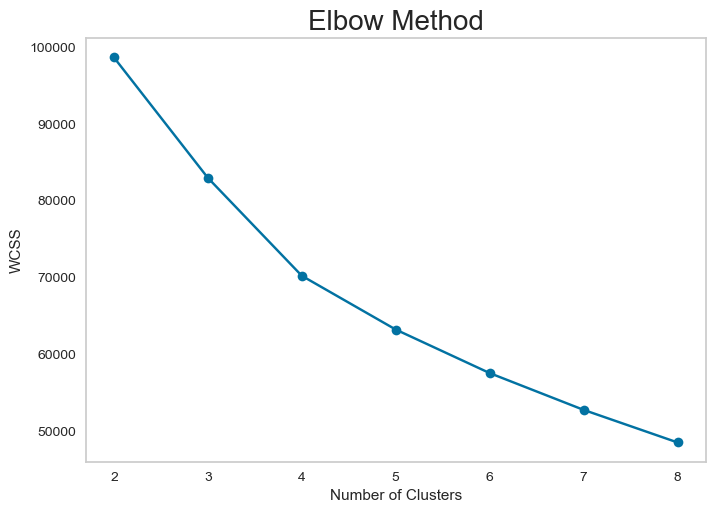

In [31]:
# Find the optimal number of clusters using Elbow Method
from sklearn.cluster import KMeans

wcss = []
random_state = 42
max_cluster = 8
for i in range(2, max_cluster+1):
    km = KMeans(n_clusters = i,
                init = 'k-means++',
                max_iter = 300,
                n_init = 10,
                random_state = random_state)
    km.fit(pca_data)
    wcss.append(km.inertia_)

plt.plot(range(2, max_cluster+1), wcss, marker ="o")
plt.grid()
plt.title('Elbow Method', fontsize = 20)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

n_clusters = 2 | Silhouette avg: 0.2485 | WCSS: 98639.57


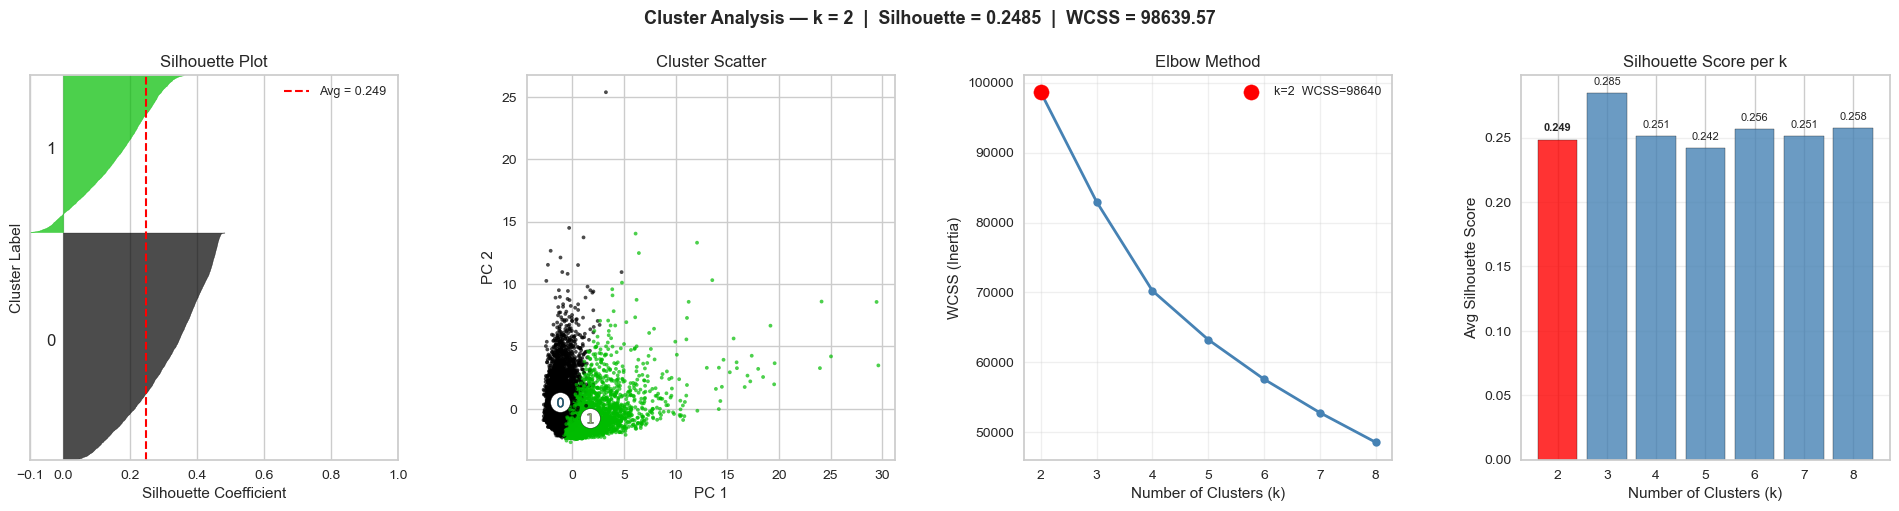

n_clusters = 3 | Silhouette avg: 0.2846 | WCSS: 82978.56


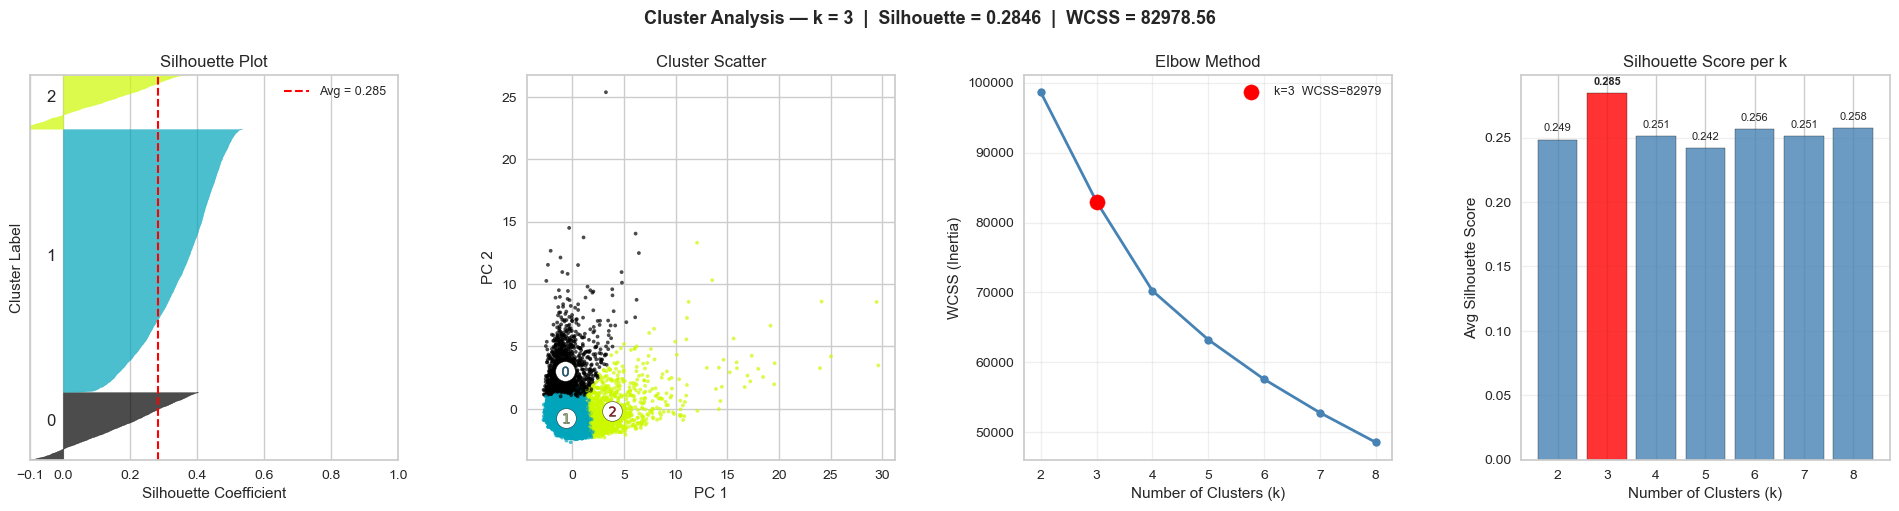

n_clusters = 4 | Silhouette avg: 0.2510 | WCSS: 70245.78


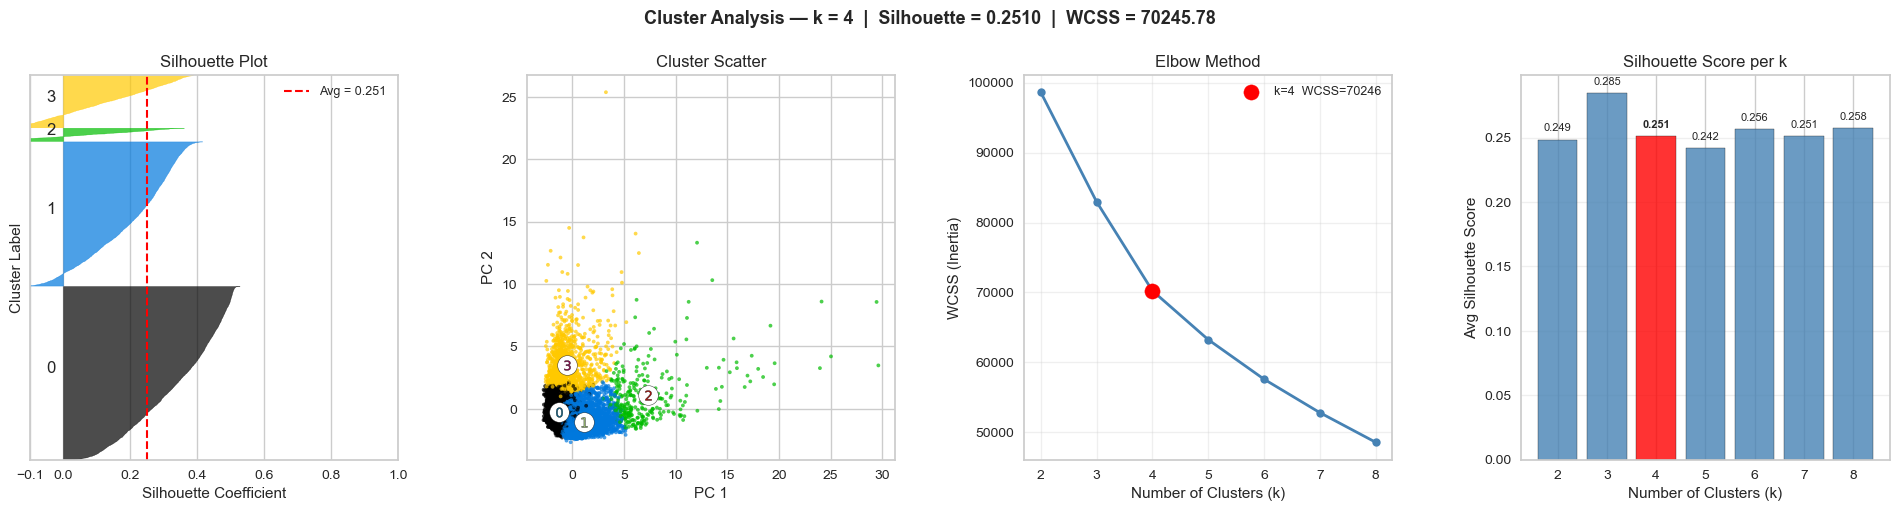

n_clusters = 5 | Silhouette avg: 0.2419 | WCSS: 63252.71


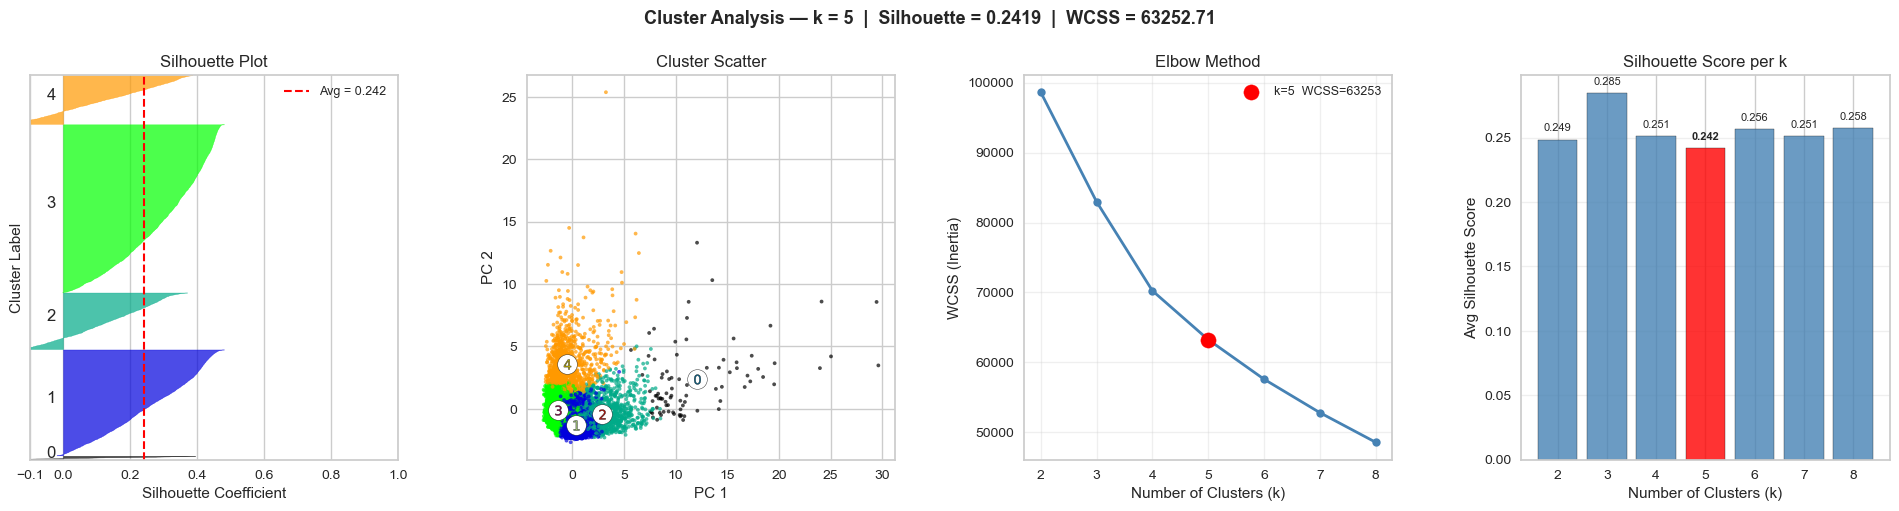

n_clusters = 6 | Silhouette avg: 0.2565 | WCSS: 57592.42


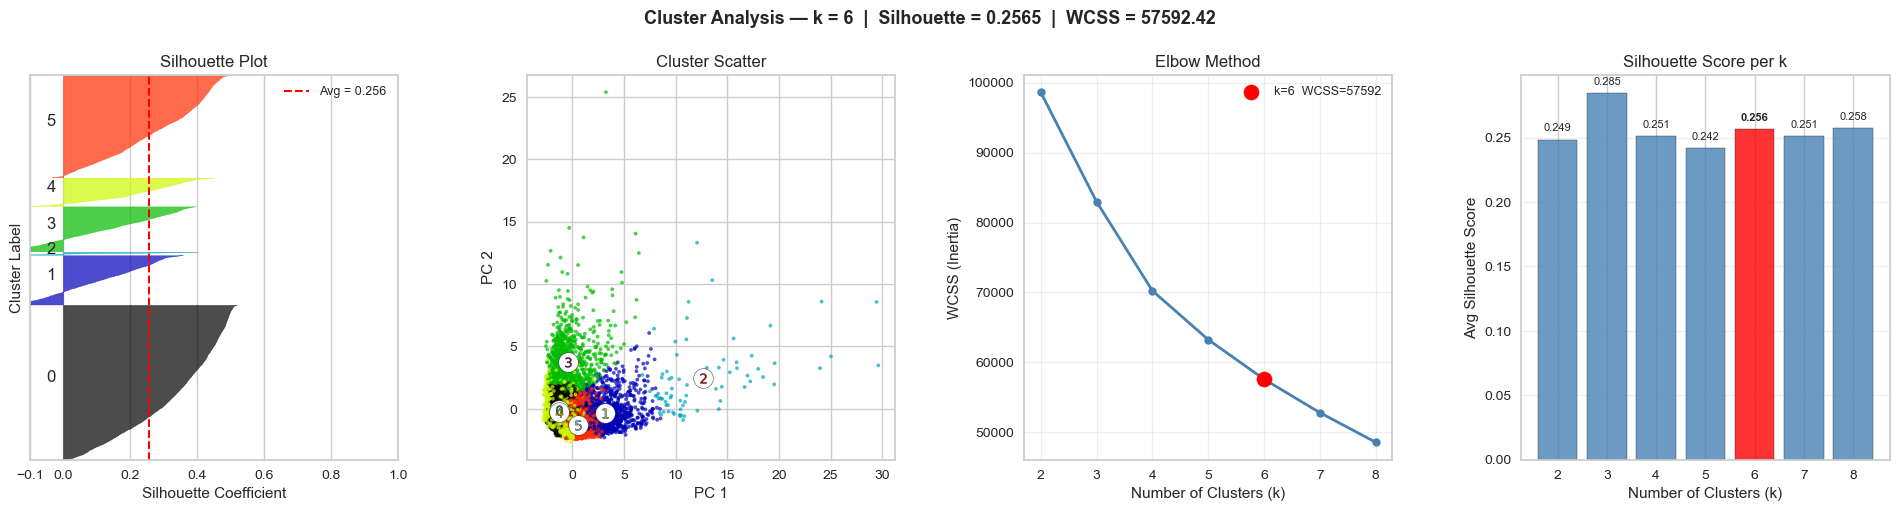

n_clusters = 7 | Silhouette avg: 0.2512 | WCSS: 52808.16


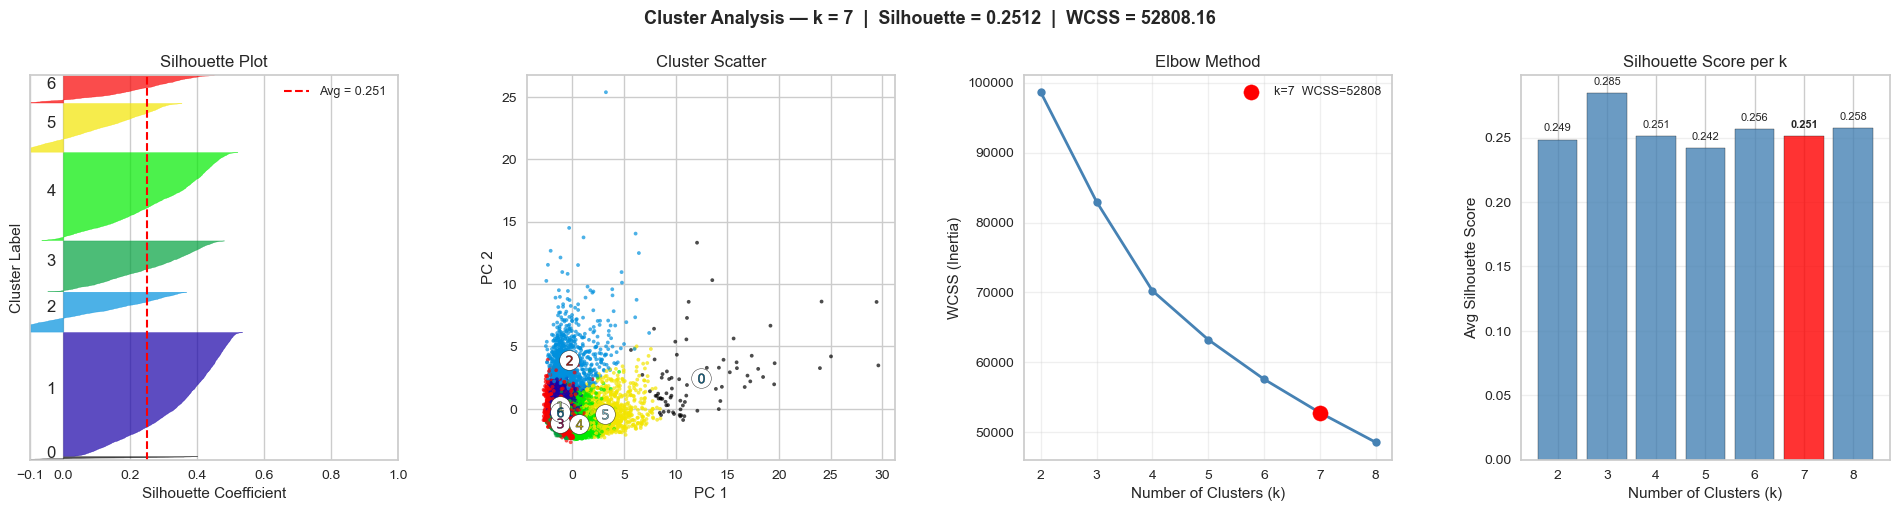

n_clusters = 8 | Silhouette avg: 0.2575 | WCSS: 48571.40


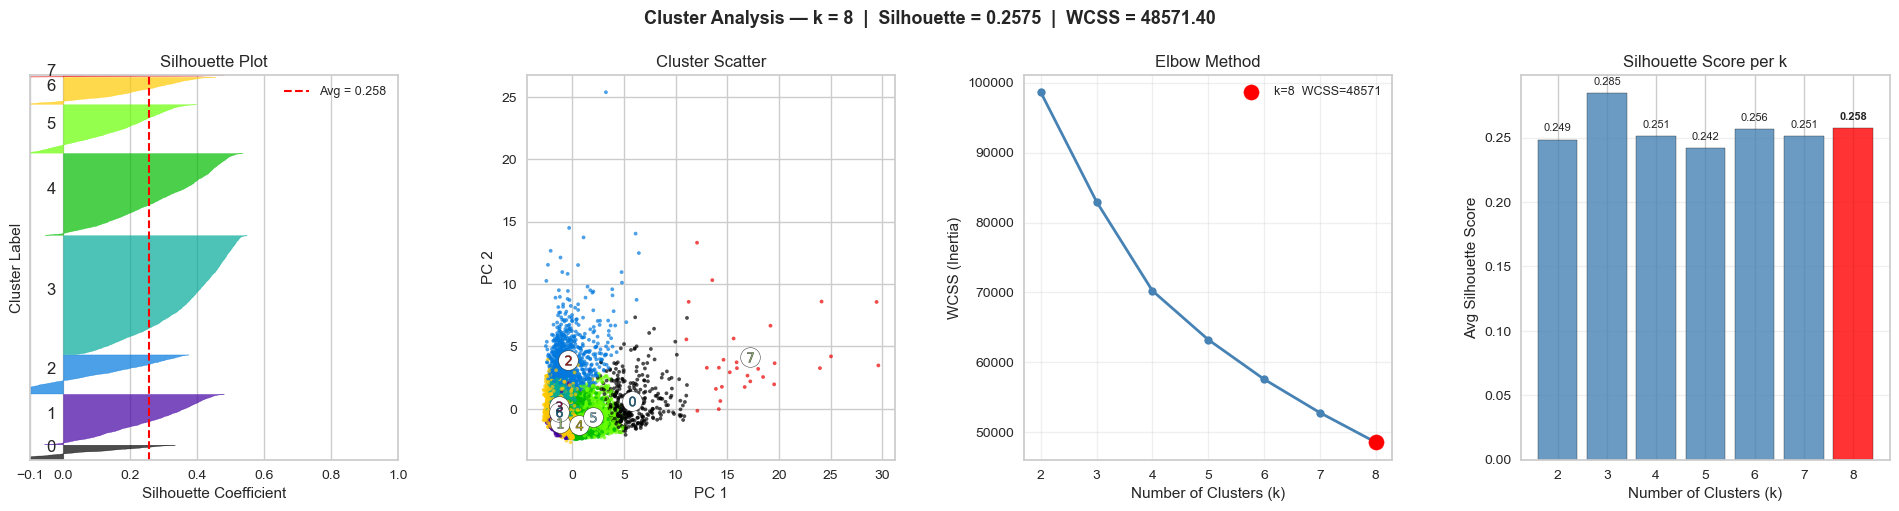

In [41]:
def plot_silhouette_elbow(range_n_clusters, X, random_state):
    
    # ── Pre-compute WCSS & Silhouette scores ──────────────────────────────────
    wcss = []
    sil_scores = []

    for k in range_n_clusters:
        km = KMeans(n_clusters=k, init='k-means++', max_iter=300,
                    n_init=10, random_state=random_state)
        labels = km.fit_predict(X)
        wcss.append(km.inertia_)
        sil_scores.append(silhouette_score(X, labels))

    # ── Per-k plot: Silhouette | Cluster Scatter | WCSS | Silhouette Bar ──────
    for idx, n_clusters in enumerate(range_n_clusters):

        # Layout: 4 kolom — [silhouette plot | scatter | elbow | sil bar]
        fig = plt.figure(figsize=(24, 5))
        gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.35)

        ax_sil    = fig.add_subplot(gs[0])   # Silhouette plot
        ax_scat   = fig.add_subplot(gs[1])   # Cluster scatter
        ax_elbow  = fig.add_subplot(gs[2])   # WCSS / Elbow
        ax_bar    = fig.add_subplot(gs[3])   # Silhouette score bar

        # ── [1] Silhouette Plot ───────────────────────────────────────────────
        ax_sil.set_xlim([-0.1, 1])
        ax_sil.set_ylim([0, len(X) + (n_clusters + 1) * 10])

        clusterer    = KMeans(n_clusters=n_clusters, init='k-means++',
                              max_iter=300, n_init=10, random_state=random_state)
        cluster_labels         = clusterer.fit_predict(X)
        silhouette_avg         = silhouette_score(X, cluster_labels)
        sample_silhouette_vals = silhouette_samples(X, cluster_labels)

        print(f"n_clusters = {n_clusters} | Silhouette avg: {silhouette_avg:.4f} | WCSS: {wcss[idx]:.2f}")

        y_lower = 10
        for i in range(n_clusters):
            ith_vals = np.sort(sample_silhouette_vals[cluster_labels == i])
            y_upper  = y_lower + ith_vals.shape[0]
            color    = cm.nipy_spectral(float(i) / n_clusters)

            ax_sil.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_vals,
                                 facecolor=color, edgecolor=color, alpha=0.7)
            ax_sil.text(-0.05, y_lower + 0.5 * ith_vals.shape[0], str(i))
            y_lower  = y_upper + 10

        ax_sil.axvline(x=silhouette_avg, color='red', linestyle='--', linewidth=1.5,
                       label=f'Avg = {silhouette_avg:.3f}')
        ax_sil.set_yticks([])
        ax_sil.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        ax_sil.set_xlabel('Silhouette Coefficient')
        ax_sil.set_ylabel('Cluster Label')
        ax_sil.set_title('Silhouette Plot')
        ax_sil.legend(loc='upper right', fontsize=9)

        # ── [2] Cluster Scatter ───────────────────────────────────────────────
        colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
        ax_scat.scatter(X[:, 0], X[:, 1], marker='.', s=30, lw=0,
                        alpha=0.7, c=colors, edgecolor='k')

        centers = clusterer.cluster_centers_
        ax_scat.scatter(centers[:, 0], centers[:, 1], marker='o',
                        c='white', alpha=1, s=200, edgecolor='k')
        for i, c in enumerate(centers):
            ax_scat.scatter(c[0], c[1], marker=f'${i}$', alpha=1, s=50, edgecolor='k')

        ax_scat.set_xlabel('PC 1')
        ax_scat.set_ylabel('PC 2')
        ax_scat.set_title('Cluster Scatter')

        # ── [3] Elbow / WCSS ─────────────────────────────────────────────────
        ax_elbow.plot(range_n_clusters, wcss, marker='o', color='steelblue',
                      linewidth=2, markersize=6)
        ax_elbow.scatter([n_clusters], [wcss[idx]],           # highlight k aktif
                         color='red', zorder=5, s=120,
                         label=f'k={n_clusters}  WCSS={wcss[idx]:.0f}')
        ax_elbow.set_xlabel('Number of Clusters (k)')
        ax_elbow.set_ylabel('WCSS (Inertia)')
        ax_elbow.set_title('Elbow Method')
        ax_elbow.legend(fontsize=9)
        ax_elbow.grid(True, alpha=0.3)

        # ── [4] Silhouette Score Bar ──────────────────────────────────────────
        bar_colors = ['red' if k == n_clusters else 'steelblue'
                      for k in range_n_clusters]
        ax_bar.bar(range_n_clusters, sil_scores, color=bar_colors, edgecolor='k',
                   alpha=0.8)
        ax_bar.set_xlabel('Number of Clusters (k)')
        ax_bar.set_ylabel('Avg Silhouette Score')
        ax_bar.set_title('Silhouette Score per k')
        ax_bar.set_xticks(range_n_clusters)
        ax_bar.grid(axis='y', alpha=0.3)

        # Annotate nilai di atas bar
        for k, s in zip(range_n_clusters, sil_scores):
            ax_bar.text(k, s + 0.005, f'{s:.3f}', ha='center',
                        va='bottom', fontsize=8,
                        fontweight='bold' if k == n_clusters else 'normal')

        fig.suptitle(
            f'Cluster Analysis — k = {n_clusters}  |  '
            f'Silhouette = {silhouette_avg:.4f}  |  WCSS = {wcss[idx]:.2f}',
            fontsize=13, fontweight='bold', y=1.01
        )
        plt.show()


# ── Panggil fungsi ────────────────────────────────────────────────────────────
plot_silhouette_elbow(range_n_clusters=range(2, 9), X=pca_data, random_state=42)

Memilih k = 3 , karena memiliki score sillhoute paling tinggi. artinya semua data point di suatu clusterm memiliki similaritas yang tinggi jika dibandingkan dengan cluster lain.

In [54]:
km = KMeans(n_clusters = 3, random_state = random_state)
pred = km.fit_predict(pca_data)
df['clusters'] = pred

# Task 4 — Visualisasi dan Interpretasi Cluster



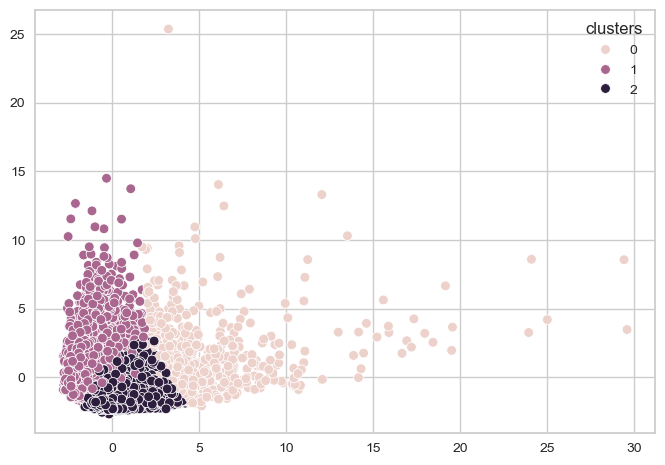

In [56]:
# Cluster visualization in 2D

pca_2d = PCA(n_components=2)
pca_2d.fit(pca_data)

sales_scaled_pca_2d = pca_2d.fit_transform(pca_data)
sns.scatterplot(x=sales_scaled_pca_2d[:,0], y=sales_scaled_pca_2d[:,1], hue=df['clusters'])
plt.show()

  Rata-rata Fitur Asli per Cluster


,Cluster 0,Cluster 1,Cluster 2
BALANCE,3870.625,1924.996,797.412
BALANCE_FREQUENCY,0.984,0.846,0.898
PURCHASES,6375.041,252.527,1084.365
ONEOFF_PURCHASES,4203.294,202.581,512.240
INSTALLMENTS_PURCHASES,2172.793,50.094,572.494
CASH_ADVANCE,1664.319,1560.456,193.685
PURCHASES_FREQUENCY,0.938,0.150,0.824
ONEOFF_PURCHASES_FREQUENCY,0.693,0.086,0.266
PURCHASES_INSTALLMENTS_FREQUENCY,0.781,0.065,0.654
CASH_ADVANCE_FREQUENCY,0.138,0.217,0.038


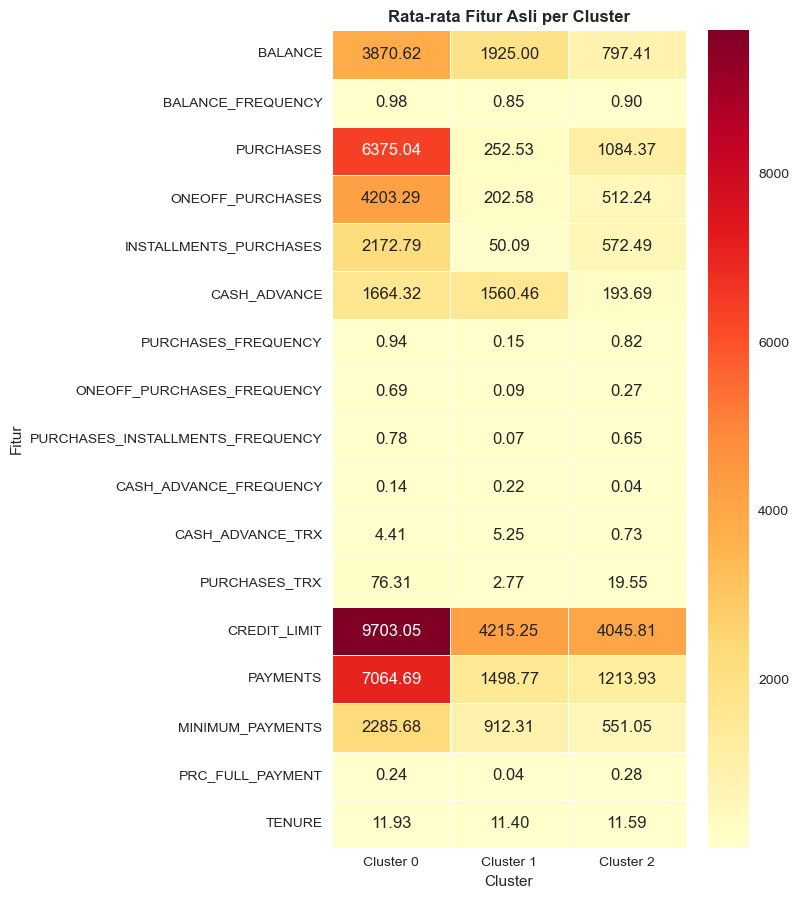

In [57]:
# df_clustered = df.copy()
# df_clustered['Cluster'] = pred

# Hitung rata-rata per cluster
cluster_means = (
    df
    .groupby('clusters')
    .mean(numeric_only=True)
    .round(3)
)

# Transpose agar fitur = baris, cluster = kolom (lebih mudah dibaca)
cluster_means_T = cluster_means.T
cluster_means_T.columns = [f'Cluster {i}' for i in cluster_means_T.columns]

print("=" * 60)
print("  Rata-rata Fitur Asli per Cluster")
print("=" * 60)
display(cluster_means_T)


# ── Heatmap untuk visualisasi tabel ──────────────────────────────────────────
import seaborn as sns

# Normalisasi per baris (per fitur) agar skala antar fitur sebanding
# cluster_means_norm = cluster_means_T.apply(
#     lambda row: (row - row.min()) / (row.max() - row.min())
#     if row.max() != row.min() else row, axis=1
# )

fig, ax = plt.subplots(figsize=(8, len(cluster_means_T) * 0.45 + 1.5))

sns.heatmap(
    cluster_means_T,
    annot=cluster_means_T,        # tampilkan nilai asli sebagai anotasi
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    ax=ax
)

ax.set_title('Rata-rata Fitur Asli per Cluster',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Fitur')
plt.tight_layout()
plt.show()


- cluster 0 (hight spender) -> cluster 0 mayoritas adalah orang yang memiliki daya beli yang tinggi, hal ini diindikasikan oleh rata rata dari kolom balance, purchase, one off purchase, installment purchase, cash advance, credit limit, payment, dan minimum payment.
- cluster 1 -> pengguna moderate, artinya pengguna yang posisi profile nya ada di antara kedua cluster lainnya. Namun PRC_FULL_PAYMENT terendah, artinya jarang bayar lunas
- cluster 2 -> pengguna dengan pengunaan kredit paling minimum dari kedua cluster. Namun PRC_FULL_PAYMENT tertinggi, artinya paling disiplin bayar lunas.

- cluster 0 -> Promosi lewat minimum pembayaran dan bonus ketika membeli sesuatu. hali ini upaya agar pengguna tidak churn
- cluster 1 -> Penawaran penggunaan kartu kredit dengan bunga rendah
- cluster 2 -> karena disiplin bayar lunas, dapat menjadikan kandidat untuk upgrade kartu